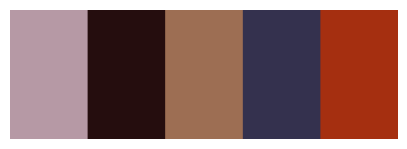

Paleta de cores em hexadecimal:
#b699a5
#250d0e
#9d6e53
#34314e
#a52f10


In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Função para converter RGB para hexadecimal
def rgb_para_hex(rgb):
    return '#{:02x}{:02x}{:02x}'.format(int(rgb[0]), int(rgb[1]), int(rgb[2]))

# Função para obter a paleta de cores
def get_palette(image_path, num_colors=5):
    # Carrega a imagem com OpenCV
    img = cv2.imread(image_path)
    
    # Converte para RGB (OpenCV carrega as imagens no formato BGR por padrão)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Redimensiona a imagem para acelerar o processo (opcional)
    resized_img = cv2.resize(img_rgb, (600, 400), interpolation=cv2.INTER_AREA)
    
    # Transforma a imagem em uma lista de pixels
    pixels = resized_img.reshape(-1, 3)
    
    # Usa o KMeans para encontrar os clusters de cores
    kmeans = KMeans(n_clusters=num_colors)
    kmeans.fit(pixels)
    
    # Pega as cores dos clusters
    palette = kmeans.cluster_centers_.astype(int)
    
    # Converte a paleta de cores para hexadecimal
    palette_hex = [rgb_para_hex(color) for color in palette]
    
    return palette, palette_hex

# Função para plotar a paleta de cores
def plot_palette(palette):
    # Cria uma imagem com as cores da paleta
    palette_img = np.zeros((100, 300, 3), dtype=np.uint8)

    step = 300 // len(palette)
    for i, color in enumerate(palette):
        palette_img[:, i * step:(i + 1) * step, :] = color

    # Mostra a imagem da paleta
    plt.figure(figsize=(5, 2))
    plt.imshow(palette_img)
    plt.axis("off")
    plt.show()

# Exemplo de uso
image_path = 'beers.jpeg'

# Obtem a paleta de cores (RGB e Hexadecimal)
palette, palette_hex = get_palette(image_path, num_colors=5)

# Plota a paleta de cores
plot_palette(palette)

# Exibe as cores em hexadecimal
print("Paleta de cores em hexadecimal:")
for hex_color in palette_hex:
    print(hex_color)


### IMG utilizada
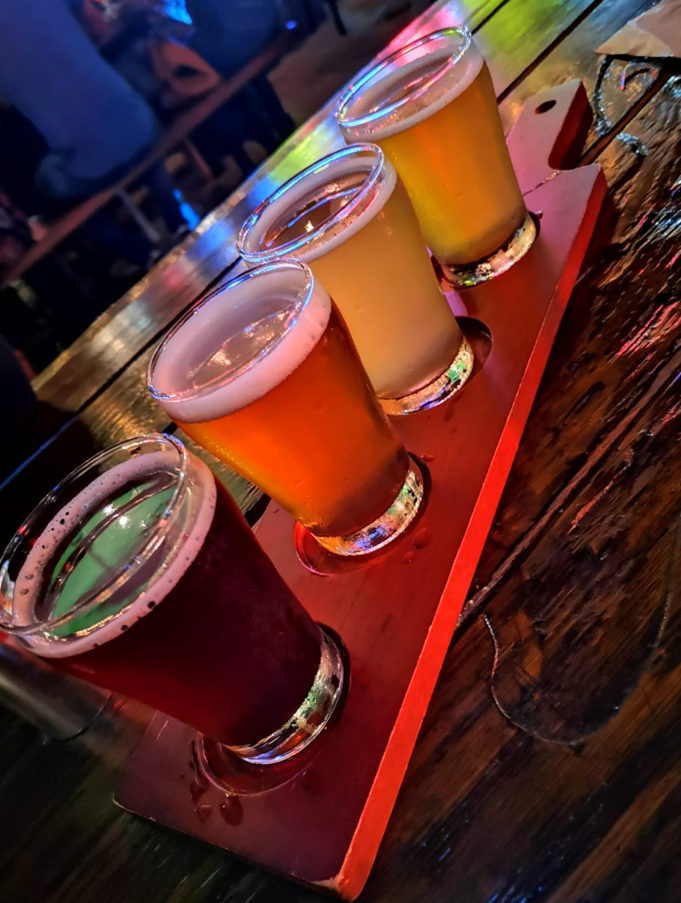